In [1]:
"""
FRESH DATA COLLECTION: 2021-2025 FROM OPEN-METEO API
Purpose: Download most recent 5 years of hourly weather data for Colombo
Date Range: 2021-01-01 to 2025-12-31
"""

import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import os
import warnings
warnings.filterwarnings('ignore')

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

print("="*70)
print("DOWNLOADING FRESH WEATHER DATA FROM OPEN-METEO API")
print("="*70)
print(f"Current date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Target period: 2021-01-01 to 2025-12-31 (5 years)")
print()

# Colombo coordinates
LATITUDE = 6.9271  # Colombo, Sri Lanka
LONGITUDE = 79.8612
LOCATION_NAME = "Colombo, Sri Lanka"

print(f"Location: {LOCATION_NAME}")
print(f"Coordinates: {LATITUDE}°N, {LONGITUDE}°E")
print()


DOWNLOADING FRESH WEATHER DATA FROM OPEN-METEO API
Current date: 2026-02-17 12:02:07
Target period: 2021-01-01 to 2025-12-31 (5 years)

Location: Colombo, Sri Lanka
Coordinates: 6.9271°N, 79.8612°E



In [2]:
"""
CELL 2: DEFINE API REQUEST FUNCTION
Open-Meteo Archive API for historical data
"""

def download_weather_data(start_date, end_date, latitude, longitude):
    """
    Download hourly weather data from Open-Meteo Archive API
    
    Parameters:
    -----------
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    latitude : float
        Latitude coordinate
    longitude : float
        Longitude coordinate
    
    Returns:
    --------
    pd.DataFrame or None
        Hourly weather data
    """
    
    # API endpoint
    base_url = "https://archive-api.open-meteo.com/v1/archive"
    
    # Weather variables to request
    hourly_variables = [
        "temperature_2m",           # Air temperature at 2m (°C)
        "relative_humidity_2m",     # Relative humidity at 2m (%)
        "dew_point_2m",            # Dew point temperature (°C)
        "precipitation",            # Precipitation (rain + snow) (mm)
        "surface_pressure",         # Surface air pressure (hPa)
        "cloud_cover",             # Total cloud cover (%)
        "wind_speed_10m",          # Wind speed at 10m (km/h)
        "wind_direction_10m"       # Wind direction at 10m (degrees)
    ]
    
    # Construct request parameters
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_variables),
        "timezone": "Asia/Colombo"  # Sri Lanka timezone (UTC+5:30)
    }
    
    print(f"\nRequesting data from Open-Meteo API...")
    print(f"  Date range: {start_date} to {end_date}")
    print(f"  Variables: {len(hourly_variables)} parameters")
    
    try:
        # Make API request
        response = requests.get(base_url, params=params, timeout=120)
        response.raise_for_status()
        
        # Parse JSON response
        data = response.json()
        
        # Extract hourly data
        hourly_data = data['hourly']
        
        # Create DataFrame
        df = pd.DataFrame({
            'datetime': pd.to_datetime(hourly_data['time']),
            'temperature_2m': hourly_data['temperature_2m'],
            'relative_humidity_2m': hourly_data['relative_humidity_2m'],
            'dew_point_2m': hourly_data['dew_point_2m'],
            'precipitation': hourly_data['precipitation'],
            'surface_pressure': hourly_data['surface_pressure'],
            'cloud_cover': hourly_data['cloud_cover'],
            'wind_speed_10m': hourly_data['wind_speed_10m'],
            'wind_direction_10m': hourly_data['wind_direction_10m']
        })
        
        print(f"✓ Successfully downloaded {len(df):,} hourly records")
        
        return df
        
    except requests.exceptions.RequestException as e:
        print(f"✗ Error downloading data: {e}")
        return None
    except KeyError as e:
        print(f"✗ Error parsing API response: {e}")
        return None
    except Exception as e:
        print(f"✗ Unexpected error: {e}")
        return None

print("✓ Data download function defined")


✓ Data download function defined


In [3]:
"""
CELL 3: DOWNLOAD DATA FOR 2021-2025
Download 5 years of hourly data in one request
"""

print("\n" + "="*70)
print("DOWNLOADING HOURLY DATA: 2021-2025")
print("="*70)

# Define date range
start_date = "2021-01-01"
end_date = "2025-12-31"

# Start timer
start_time = time.time()

# Download data
df_hourly = download_weather_data(
    start_date=start_date,
    end_date=end_date,
    latitude=LATITUDE,
    longitude=LONGITUDE
)

# Calculate elapsed time
elapsed_time = time.time() - start_time

if df_hourly is not None:
    print(f"\n{'='*70}")
    print(f"DOWNLOAD SUCCESSFUL")
    print(f"{'='*70}")
    print(f"  Time taken: {elapsed_time:.1f} seconds")
    print(f"  Records: {len(df_hourly):,}")
    print(f"  Date range: {df_hourly['datetime'].min()} to {df_hourly['datetime'].max()}")
    print(f"  Total days: {len(df_hourly) / 24:.1f}")
    print(f"  Total months: {(df_hourly['datetime'].max() - df_hourly['datetime'].min()).days / 30.5:.1f}")
    
    # Display first few records
    print(f"\nFirst 5 records:")
    print(df_hourly.head())
    
    # Display last few records
    print(f"\nLast 5 records:")
    print(df_hourly.tail())
else:
    print(f"\n✗ Download failed. Please check your internet connection and try again.")



DOWNLOADING HOURLY DATA: 2021-2025

Requesting data from Open-Meteo API...
  Date range: 2021-01-01 to 2025-12-31
  Variables: 8 parameters
✓ Successfully downloaded 43,824 hourly records

DOWNLOAD SUCCESSFUL
  Time taken: 2.7 seconds
  Records: 43,824
  Date range: 2021-01-01 00:00:00 to 2025-12-31 23:00:00
  Total days: 1826.0
  Total months: 59.8

First 5 records:
             datetime  temperature_2m  relative_humidity_2m  dew_point_2m  \
0 2021-01-01 00:00:00            24.1                    96          23.4   
1 2021-01-01 01:00:00            23.7                    96          23.0   
2 2021-01-01 02:00:00            23.2                    96          22.4   
3 2021-01-01 03:00:00            22.5                    98          22.1   
4 2021-01-01 04:00:00            22.5                    98          22.1   

   precipitation  surface_pressure  cloud_cover  wind_speed_10m  \
0            0.0            1009.2           43             4.2   
1            0.0            1008

In [4]:
"""
CELL 4: QUICK DATA QUALITY CHECK
Check for missing values and basic statistics
"""

if df_hourly is not None:
    print("\n" + "="*70)
    print("DATA QUALITY CHECK")
    print("="*70)
    
    # Missing values
    print("\n1. Missing Values:")
    missing = df_hourly.isnull().sum()
    missing_pct = (missing / len(df_hourly) * 100).round(2)
    
    print(f"   {'Variable':<30} {'Missing':>10} {'%':>8}")
    print(f"   {'-'*50}")
    for col in df_hourly.columns:
        if col != 'datetime':
            print(f"   {col:<30} {missing[col]:>10,} {missing_pct[col]:>7.2f}%")
    
    total_missing = missing.sum()
    total_cells = len(df_hourly) * (len(df_hourly.columns) - 1)
    overall_missing_pct = (total_missing / total_cells * 100)
    
    print(f"\n   Overall: {total_missing:,} missing values ({overall_missing_pct:.2f}%)")
    
    if overall_missing_pct < 1:
        print(f"   ✓ Excellent data quality!")
    elif overall_missing_pct < 5:
        print(f"   ✓ Good data quality")
    else:
        print(f"   ⚠ Some missing data - will handle in preprocessing")
    
    # Basic statistics
    print(f"\n2. Weather Variable Ranges:")
    print(f"   {'Variable':<30} {'Min':>10} {'Max':>10} {'Mean':>10}")
    print(f"   {'-'*62}")
    
    for col in ['temperature_2m', 'relative_humidity_2m', 'precipitation', 
                'surface_pressure', 'wind_speed_10m']:
        if col in df_hourly.columns:
            min_val = df_hourly[col].min()
            max_val = df_hourly[col].max()
            mean_val = df_hourly[col].mean()
            print(f"   {col:<30} {min_val:>10.2f} {max_val:>10.2f} {mean_val:>10.2f}")
    
    # Rainfall statistics
    print(f"\n3. Rainfall Statistics:")
    rainy_hours = (df_hourly['precipitation'] > 0).sum()
    rainy_pct = (rainy_hours / len(df_hourly) * 100)
    total_rain = df_hourly['precipitation'].sum()
    max_hourly = df_hourly['precipitation'].max()
    
    print(f"   Rainy hours: {rainy_hours:,} ({rainy_pct:.1f}%)")
    print(f"   Dry hours: {len(df_hourly) - rainy_hours:,} ({100-rainy_pct:.1f}%)")
    print(f"   Total rainfall: {total_rain:,.1f} mm")
    print(f"   Max hourly: {max_hourly:.1f} mm")
    print(f"   Mean hourly: {df_hourly['precipitation'].mean():.3f} mm")
    
    # Temperature check
    print(f"\n4. Temperature Check:")
    print(f"   Hottest recorded: {df_hourly['temperature_2m'].max():.1f}°C")
    print(f"   Coolest recorded: {df_hourly['temperature_2m'].min():.1f}°C")
    print(f"   Average: {df_hourly['temperature_2m'].mean():.1f}°C")
    
    # Year-by-year summary
    print(f"\n5. Year-by-Year Summary:")
    df_hourly['year'] = df_hourly['datetime'].dt.year
    yearly_summary = df_hourly.groupby('year').agg({
        'precipitation': ['sum', 'count'],
        'temperature_2m': 'mean'
    }).round(2)
    yearly_summary.columns = ['Total_Rainfall_mm', 'Hours', 'Avg_Temp_C']
    print(yearly_summary)



DATA QUALITY CHECK

1. Missing Values:
   Variable                          Missing        %
   --------------------------------------------------
   temperature_2m                          0    0.00%
   relative_humidity_2m                    0    0.00%
   dew_point_2m                            0    0.00%
   precipitation                           0    0.00%
   surface_pressure                        0    0.00%
   cloud_cover                             0    0.00%
   wind_speed_10m                          0    0.00%
   wind_direction_10m                      0    0.00%

   Overall: 0 missing values (0.00%)
   ✓ Excellent data quality!

2. Weather Variable Ranges:
   Variable                              Min        Max       Mean
   --------------------------------------------------------------
   temperature_2m                      18.20      35.40      26.57
   relative_humidity_2m                27.00     100.00      83.90
   precipitation                        0.00      38.90  

In [5]:
"""
CELL 5: SAVE DOWNLOADED DATA
Save raw hourly data to CSV file
"""

if df_hourly is not None:
    print("\n" + "="*70)
    print("SAVING DOWNLOADED DATA")
    print("="*70)
    
    # Save to CSV
    output_file = 'data/colombo_hourly_raw_2021_2025.csv'
    df_hourly.to_csv(output_file, index=False)
    
    # File size
    file_size_mb = os.path.getsize(output_file) / (1024 * 1024)
    
    print(f"\n✓ Data saved successfully!")
    print(f"  File: {output_file}")
    print(f"  Size: {file_size_mb:.2f} MB")
    print(f"  Records: {len(df_hourly):,} rows")
    print(f"  Variables: {len(df_hourly.columns)} columns")
    print(f"  Date range: {df_hourly['datetime'].min().date()} to {df_hourly['datetime'].max().date()}")
    
    print(f"\n{'='*70}")
    print(f"DATA COLLECTION COMPLETE!")
    print(f"{'='*70}")
    print(f"\nYou now have fresh hourly weather data for 2021-2025")
    print(f"Ready to proceed with Phase 1: Data Preparation")
    print(f"\nNext steps:")
    print(f"  1. Calculate 24-hour rolling target variable")
    print(f"  2. Create daily aggregates and lag features")
    print(f"  3. Engineer rolling window features")
    print(f"  4. Prepare train/validation/test splits")
else:
    print("\n✗ No data to save. Please re-run the download.")



SAVING DOWNLOADED DATA

✓ Data saved successfully!
  File: data/colombo_hourly_raw_2021_2025.csv
  Size: 2.58 MB
  Records: 43,824 rows
  Variables: 10 columns
  Date range: 2021-01-01 to 2025-12-31

DATA COLLECTION COMPLETE!

You now have fresh hourly weather data for 2021-2025
Ready to proceed with Phase 1: Data Preparation

Next steps:
  1. Calculate 24-hour rolling target variable
  2. Create daily aggregates and lag features
  3. Engineer rolling window features
  4. Prepare train/validation/test splits



CREATING VISUALIZATION

✓ Visualization saved: data/downloaded_data_overview.png


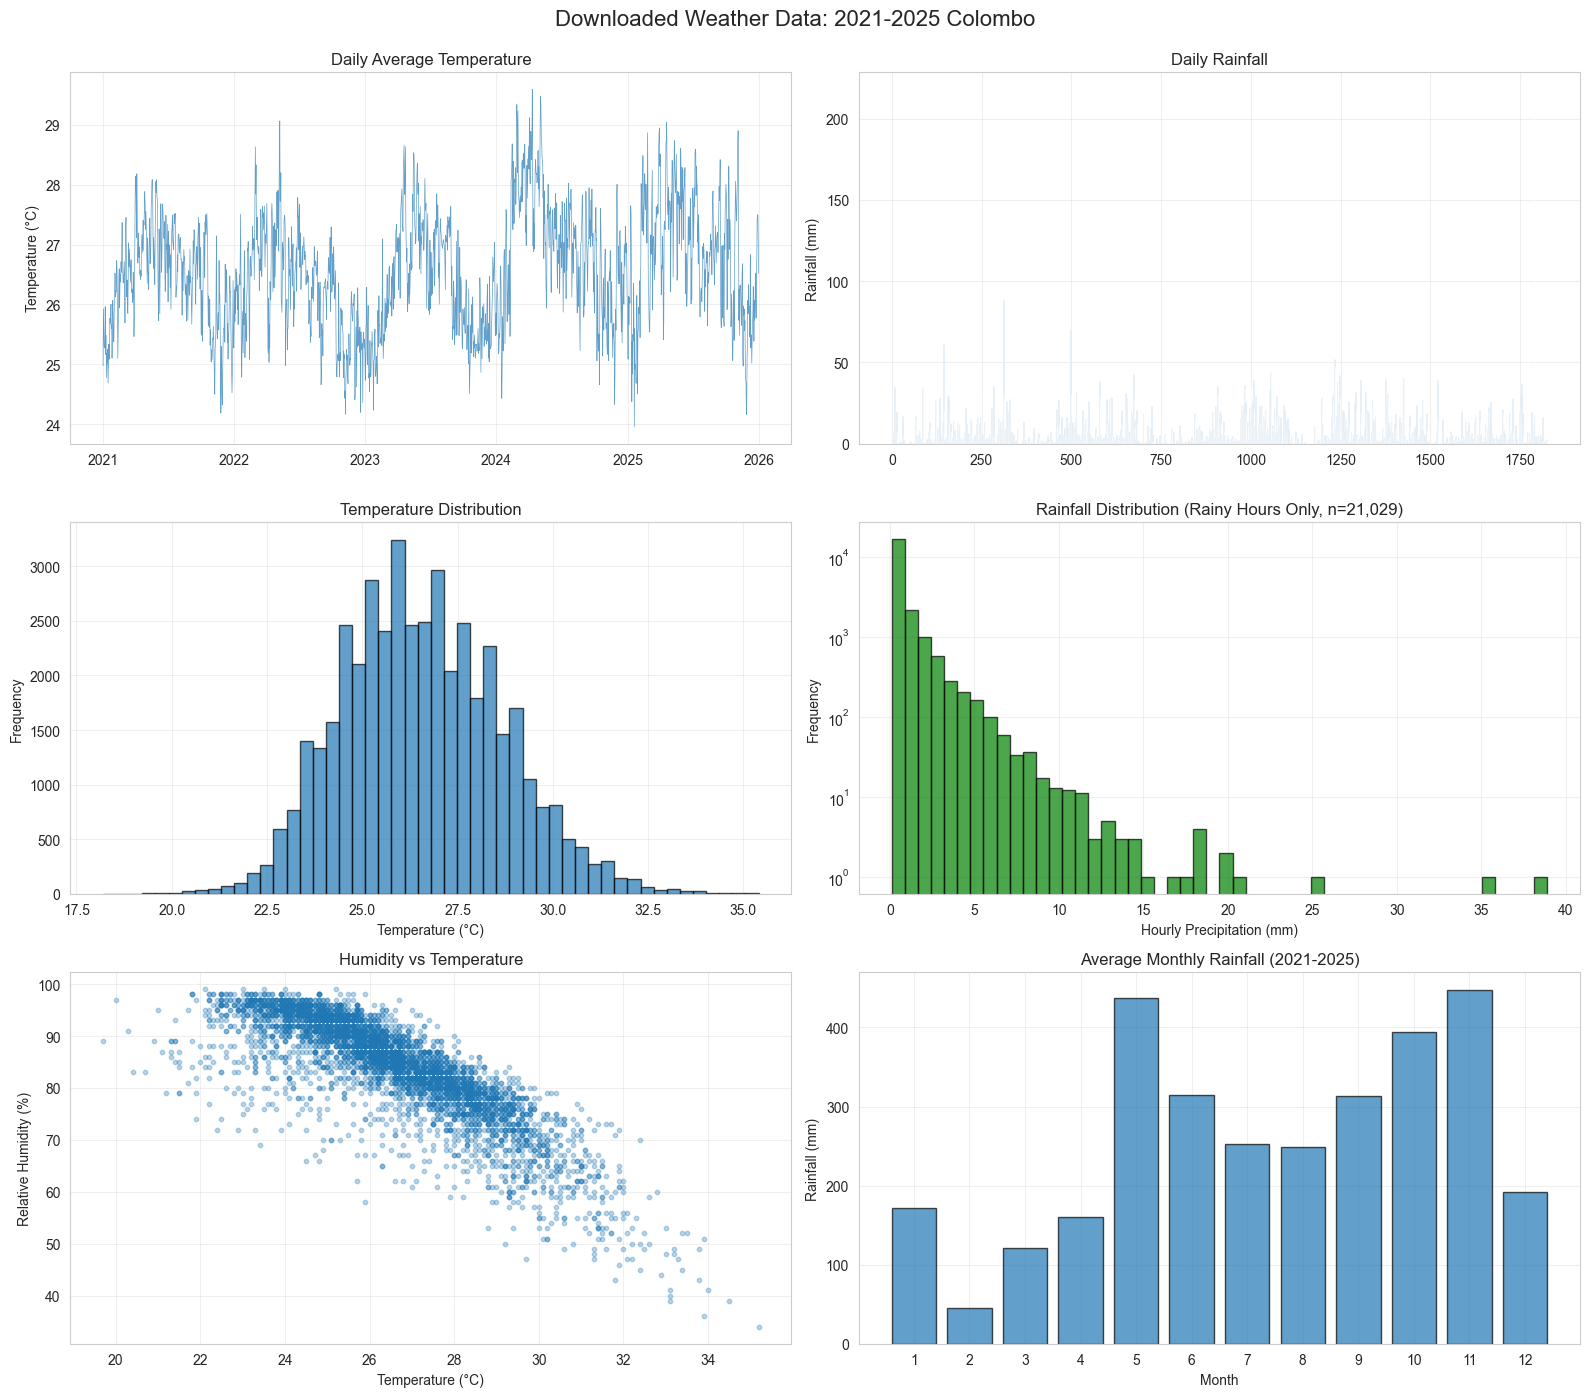


✓ Data download and validation complete!
  All checks passed - ready for modeling!


In [6]:
"""
CELL 6: QUICK VISUALIZATION OF DOWNLOADED DATA
Visual check of the data quality and patterns
"""

if df_hourly is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    sns.set_style("whitegrid")
    
    print("\n" + "="*70)
    print("CREATING VISUALIZATION")
    print("="*70)
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('Downloaded Weather Data: 2021-2025 Colombo', fontsize=16, y=0.995)
    
    # Plot 1: Temperature time series
    df_hourly['date'] = df_hourly['datetime'].dt.date
    daily_temp = df_hourly.groupby('date')['temperature_2m'].mean()
    axes[0, 0].plot(daily_temp.index, daily_temp.values, linewidth=0.5, alpha=0.7)
    axes[0, 0].set_title('Daily Average Temperature')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Daily rainfall
    daily_rain = df_hourly.groupby('date')['precipitation'].sum()
    axes[0, 1].bar(range(len(daily_rain)), daily_rain.values, width=1, alpha=0.7)
    axes[0, 1].set_title('Daily Rainfall')
    axes[0, 1].set_ylabel('Rainfall (mm)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Temperature distribution
    axes[1, 0].hist(df_hourly['temperature_2m'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Temperature Distribution')
    axes[1, 0].set_xlabel('Temperature (°C)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Rainfall distribution (non-zero only)
    rain_data = df_hourly[df_hourly['precipitation'] > 0]['precipitation']
    axes[1, 1].hist(rain_data, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[1, 1].set_title(f'Rainfall Distribution (Rainy Hours Only, n={len(rain_data):,})')
    axes[1, 1].set_xlabel('Hourly Precipitation (mm)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 5: Humidity vs Temperature
    sample = df_hourly.sample(min(5000, len(df_hourly)))
    axes[2, 0].scatter(sample['temperature_2m'], sample['relative_humidity_2m'], 
                      alpha=0.3, s=10)
    axes[2, 0].set_title('Humidity vs Temperature')
    axes[2, 0].set_xlabel('Temperature (°C)')
    axes[2, 0].set_ylabel('Relative Humidity (%)')
    axes[2, 0].grid(True, alpha=0.3)
    
    # Plot 6: Monthly rainfall pattern
    df_hourly['month'] = df_hourly['datetime'].dt.month
    monthly_rain = df_hourly.groupby('month')['precipitation'].sum() / 5  # Average over 5 years
    axes[2, 1].bar(monthly_rain.index, monthly_rain.values, edgecolor='black', alpha=0.7)
    axes[2, 1].set_title('Average Monthly Rainfall (2021-2025)')
    axes[2, 1].set_xlabel('Month')
    axes[2, 1].set_ylabel('Rainfall (mm)')
    axes[2, 1].set_xticks(range(1, 13))
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plot_file = 'data/downloaded_data_overview.png'
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    print(f"\n✓ Visualization saved: {plot_file}")
    plt.show()
    
    print(f"\n✓ Data download and validation complete!")
    print(f"  All checks passed - ready for modeling!")
